In [ ]:
#all imports 
import os
import sys
import math
import pickle
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo

warnings.filterwarnings('ignore')


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from factor_analyzer import factor_analyzer
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder


In [9]:
#ass-1 beml 
df=pd.read_csv("BEML.csv")
df.head(5)
df[['Date','Open']].head()

,Date,Open
0,2010-01-04,1121.0
1,2010-01-05,1146.8
2,2010-01-06,1140.0
3,2010-01-07,1142.0
4,2010-01-08,1156.0


In [10]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Last', 'Close', 'Total Trade Quantity',
       'Turnover (Lacs)'],
      dtype='object')

In [11]:
df['Gain']=df['Close']-df['Open']
df.head(5)

,Date,Open,High,Low,Last,Close,Total Trade Quantity,Turnover (Lacs),Gain
0,2010-01-04,1121.0,1151.00,1121.00,1134.0,1135.60,101651.0,1157.18,14.60
1,2010-01-05,1146.8,1149.00,1128.75,1135.0,1134.60,59504.0,676.47,-12.20
2,2010-01-06,1140.0,1164.25,1130.05,1137.0,1139.60,128908.0,1482.84,-0.40
3,2010-01-07,1142.0,1159.40,1119.20,1141.0,1144.15,117871.0,1352.98,2.15
4,2010-01-08,1156.0,1172.00,1140.00,1141.2,1144.05,170063.0,1971.42,-11.95


In [12]:
profit_days = df[df['Gain'] > 0]
loss_days = df[df['Gain'] < 0]

print("Profit Days:", profit_days.shape[0])
print("Loss Days:", loss_days.shape[0])

Profit Days: 732
Loss Days: 1000


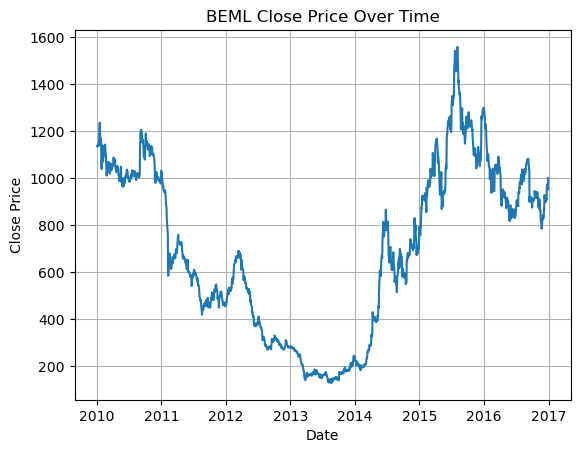

In [16]:
#plt.figure(figsize=(10,5))
plt.plot(pd.to_datetime(df['Date']), df['Close'])
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("BEML Close Price Over Time")
plt.grid(True)
plt.show()

In [17]:
#ass-2
new_df=pd.read_csv('Glaxo.csv')
new_df.head()

,Date,Open,High,Low,Last,Close,Total Trade Quantity,Turnover (Lacs)
0,2010-01-04,1613.00,1629.10,1602.00,1629.0,1625.65,9365.0,151.74
1,2010-01-05,1639.95,1639.95,1611.05,1620.0,1616.80,38148.0,622.58
2,2010-01-06,1618.00,1644.00,1617.00,1639.0,1638.50,36519.0,595.09
3,2010-01-07,1645.00,1654.00,1636.00,1648.0,1648.70,12809.0,211.00
4,2010-01-08,1650.00,1650.00,1626.55,1640.0,1639.80,28035.0,459.11


In [19]:
new_df_1=new_df.drop(columns=[col for col in new_df.columns if col not in ['Date','Close']])
new_df_1.head()

,Date,Close
0,2010-01-04,1625.65
1,2010-01-05,1616.80
2,2010-01-06,1638.50
3,2010-01-07,1648.70
4,2010-01-08,1639.80


In [20]:
#convert time attribute to index
new_df_1['Date']=pd.to_datetime(new_df_1['Date'])
new_df_1.set_index('Date',inplace=True)
new_df_1.head()

,Close
Date,
2010-01-04,1625.65
2010-01-05,1616.80
2010-01-06,1638.50
2010-01-07,1648.70
2010-01-08,1639.80


In [22]:
new_df_1.isnull().sum()
new_df_1.fillna(method='ffill', inplace=True)

C:\Users\Aditya\AppData\Local\Temp\ipykernel_26972\3686685592.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  new_df_1.fillna(method='ffill', inplace=True)


C:\Users\Aditya\anaconda3\Anaconda_Navigator\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


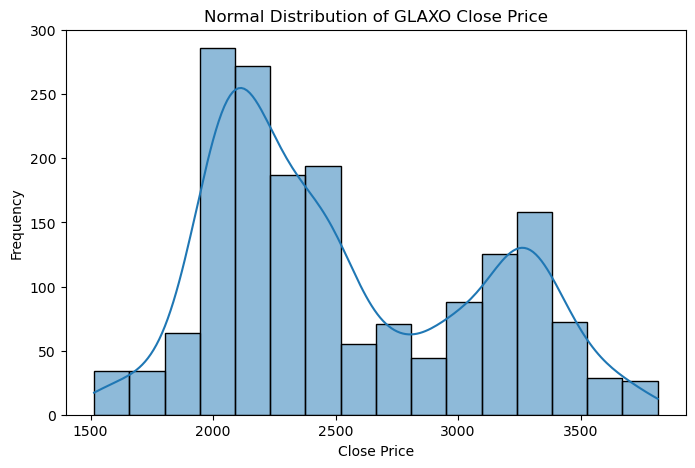

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(new_df['Close'], kde=True)
plt.title("Normal Distribution of GLAXO Close Price")
plt.xlabel("Close Price")
plt.ylabel("Frequency")
plt.show()

In [24]:
#create new csv file of new dataframe
new_df_1.to_csv("Glaxo_New_Data.csv")

In [25]:

#use bml dataset
data = df[['Open', 'Close']].copy()

data['Gain_Loss'] = np.where(data['Close'] > data['Open'], 'Gain', 'Loss')

data['Price_Category'] = pd.cut(
    data['Close'],
    bins=3,
    labels=['Low', 'Medium', 'High']
)
data.head()

,Open,Close,Gain_Loss,Price_Category
0,1121.0,1135.60,Gain,High
1,1146.8,1134.60,Loss,High
2,1140.0,1139.60,Loss,High
3,1142.0,1144.15,Gain,High
4,1156.0,1144.05,Loss,High


In [28]:
cv=data[['Open', 'Close']].cov()
cor=data[['Open', 'Close']].corr()

,Open,Close
Open,1.000000,0.998726
Close,0.998726,1.000000


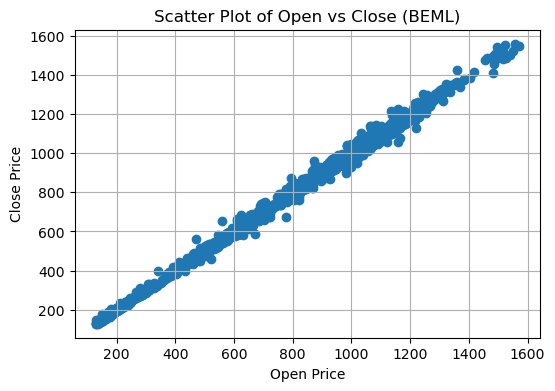

In [29]:
plt.figure(figsize=(6,4))
plt.scatter(data['Open'], data['Close'])
plt.xlabel("Open Price")
plt.ylabel("Close Price")
plt.title("Scatter Plot of Open vs Close (BEML)")
plt.grid(True)
plt.show()

In [30]:
Q1 = data[['Open', 'Close']].quantile(0.25)
Q3 = data[['Open', 'Close']].quantile(0.75)
IQR = Q3 - Q1

clean_data = data[~((data[['Open', 'Close']] < (Q1 - 1.5 * IQR)) |
                    (data[['Open', 'Close']] > (Q3 + 1.5 * IQR))).any(axis=1)]

clean_data.shape

(1739, 4)

In [ ]:
#ass-3 univariate and bivariate analysis
data = {
    'name': ['Amit', 'Anshul', 'Rushi', 'Omkar', 'Sanjyot', 'Nikhil'],
    'city': ['Pune', 'Mumbai', 'Pune', 'Delhi', 'Mumbai', 'Delhi'],
    'score1': [78, 85, 88, 76, 90, 82],
    'score2': [80, 83, 91, 79, 88, 84]
}

df = pd.DataFrame(data)
df
df.describe(include='all')
df.mean(numeric_only=True)
df.median(numeric_only=True)
df.mode()
plt.figure(figsize=(8,4))
sns.boxplot(data=df[['score1', 'score2']])
plt.title("Box Plot of Score1 and Score2")
plt.show()

df.groupby('city')['score1'].mean()
df.groupby('name')['score2'].mean()

plt.figure(figsize=(6,4))
plt.scatter(df['score1'], df['score2'])
plt.xlabel("Score1")
plt.ylabel("Score2")
plt.title("Scatter Plot between Score1 and Score2")
plt.grid(True)
plt.show()


pivot_table = pd.pivot_table(
    df,
    values='score1',
    index='name',
    columns='city',
    aggfunc='mean'
)

sns.heatmap(pivot_table, annot=True, cmap='coolwarm')
plt.title("Heatmap between Name and City")
plt.show()

In [32]:
#ass-4 random sampling and stratified sampling
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder



In [50]:
titanic_data=pd.read_csv('titanic.csv')
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [51]:
titanic_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [52]:
titanic_data['Age'].fillna(titanic_data['Age'].median(), inplace=True)
titanic_data['Embarked'].fillna('S', inplace=True)

In [53]:
titanic_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [54]:
titanic_data.drop(['Cabin','Ticket','Name'], axis=1, inplace=True)

In [55]:
titanic_data['Sex'] = LabelEncoder().fit_transform(titanic_data['Sex'])

In [56]:
titanic_data.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,1,22.0,1,0,7.2500,S
1,2,1,1,0,38.0,1,0,71.2833,C
2,3,1,3,0,26.0,0,0,7.9250,S
3,4,1,1,0,35.0,1,0,53.1000,S
4,5,0,3,1,35.0,0,0,8.0500,S


In [57]:
titanic_data['FamilySize'] = titanic_data['SibSp'] + titanic_data['Parch'] + 1

In [58]:
titanic_data.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize
0,1,0,3,1,22.0,1,0,7.2500,S,2
1,2,1,1,0,38.0,1,0,71.2833,C,2
2,3,1,3,0,26.0,0,0,7.9250,S,1
3,4,1,1,0,35.0,1,0,53.1000,S,2
4,5,0,3,1,35.0,0,0,8.0500,S,1


In [59]:
X = titanic_data[['Pclass','Sex','Age','FamilySize','Fare']]
y = titanic_data['Survived']

In [60]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y, test_size=0.2, random_state=42)
rf_r = RandomForestClassifier(random_state=42).fit(X_train_r, y_train_r)
print("Random Acc:", accuracy_score(y_test_r, rf_r.predict(X_test_r)))

Random Acc: 0.8044692737430168


In [61]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
rf_s = RandomForestClassifier(random_state=42).fit(X_train_s, y_train_s)
print("Stratified Acc:", accuracy_score(y_test_s, rf_s.predict(X_test_s)))
print(classification_report(y_test_s, rf_s.predict(X_test_s)))

Stratified Acc: 0.8100558659217877
              precision    recall  f1-score   support

           0       0.83      0.86      0.85       110
           1       0.77      0.72      0.75        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179



In [65]:
#ass-5 naive bayes
import pandas as pd
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


import pickle

In [66]:
data = load_breast_cancer()
X = data.data     #feature
y = data.target  #target (0: malignant, 1: benign)

In [67]:
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Number of outcome classes:", len(np.unique(y)))
print("Outcome labels:", data.target_names)

Number of samples: 569
Number of features: 30
Number of outcome classes: 2
Outcome labels: ['malignant' 'benign']


In [69]:
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [70]:
df['target'].value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

In [76]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
accuracy
precision = precision_score(y_test, y_pred)
precision
recall = recall_score(y_test, y_pred)
recall
confusion_matrix(y_test, y_pred)
print(classification_report(y_test, y_pred, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       1.00      0.93      0.96        43
      benign       0.96      1.00      0.98        71

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



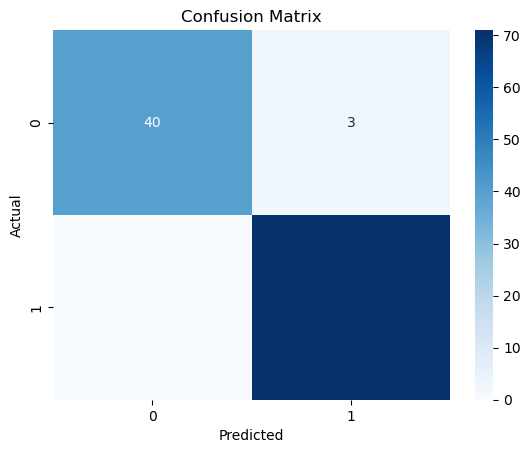

In [77]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [78]:
with open("naive_bayes_breast_cancer.pkl", "wb") as file:
    pickle.dump(model, file)

In [81]:
#inferencing in new notebook
import pickle
import numpy as np
from sklearn.datasets import load_breast_cancer

model = pickle.load(open('naive_bayes_breast_cancer.pkl', 'rb'))
data = load_breast_cancer()
X = data.data

# Predict on first 5 samples
predictions = model.predict(X[:5])
print("Predictions (0=malignant, 1=benign):", predictions)
print("Actual:", data.target[:5])

# New sample inference (example tumor data)
new_sample = X[0].reshape(1, -1)  # Reshape for prediction
result = model.predict(new_sample)[0]
prob = model.predict_proba(new_sample)[0]
print(f"New sample prediction: {result} (Prob: {prob})")


Predictions (0=malignant, 1=benign): [0 0 0 0 0]
Actual: [0 0 0 0 0]
New sample prediction: 0 (Prob: [1.00000000e+000 8.42065849e-140])


In [82]:
#ass-7  
import os
import sys

os.environ['PYTHON_HOME'] = sys.executable
os.environ['PYTHON_DRIVER_HOME'] = sys.executable
os.environ['JAVA_HOME'] = r'D:\Java'

In [83]:
import math
from scipy.stats import binom

In [86]:
n=10
m=0.08

In [87]:
#a) 
prob_all10=binom.pmf(10,n,m)
print('Probability of all 10 men are color blind',prob_all10)

#b) 
prob_all0=binom.pmf(0,n,m)
print('Probability of no men are color blind',prob_all0)

#c) 
prob_all2=binom.pmf(2,n,m)
print('Probability of all 2 men are color blind',prob_all2)

#d)
probab_atleast2=1-(binom.pmf(0,n,m)+binom.pmf(1,n,m))
print('Probability of atleast 2 men are color blind',probab_atleast2)

Probability of all 10 men are color blind 1.0737418240000003e-11
Probability of no men are color blind 0.4343884542236322
Probability of all 2 men are color blind 0.14780703546361773
Probability of atleast 2 men are color blind 0.18788245514712254


In [88]:
from scipy.stats import poisson

In [89]:
prob_max_5=poisson.cdf(5,10)
print('probability that the number of calls will be maximum 5:',prob_max_5)

prob_3hr=poisson.cdf(30,30)
print('probability number of calls over a 3 hour period will exceed 30 calls :',prob_3hr)

probability that the number of calls will be maximum 5: 0.06708596287903189
probability number of calls over a 3 hour period will exceed 30 calls : 0.5483515125779114


In [95]:
#ass-7
import pandas as pd
import numpy as np
import warnings
beml_df=pd.read_csv('BEML.csv')
beml_df.head(5)

#glaxo_df=pd.read_csv('GLAXO.csv')
#glaxo_df.head(5)

,Date,Open,High,Low,Last,Close,Total Trade Quantity,Turnover (Lacs)
0,2010-01-04,1121.0,1151.00,1121.00,1134.0,1135.60,101651.0,1157.18
1,2010-01-05,1146.8,1149.00,1128.75,1135.0,1134.60,59504.0,676.47
2,2010-01-06,1140.0,1164.25,1130.05,1137.0,1139.60,128908.0,1482.84
3,2010-01-07,1142.0,1159.40,1119.20,1141.0,1144.15,117871.0,1352.98
4,2010-01-08,1156.0,1172.00,1140.00,1141.2,1144.05,170063.0,1971.42


In [96]:
beml_df=beml_df[['Date','Close']]
glaxo_df=glaxo_df[['Date','Close']]

beml_df=beml_df.set_index(pd.DatetimeIndex(beml_df['Date']))
glaxo_df=glaxo_df.set_index(pd.DatetimeIndex(glaxo_df['Date']))

import matplotlib.pyplot as plt
import seaborn as sn
plt.plot(beml_df.Close)
plt.xlabel('Time')
plt.ylabel('Close price')

import matplotlib.pyplot as plt
import seaborn as sn
plt.plot(glaxo_df.Close)
plt.xlabel('Time')
plt.ylabel('Close price')

beml_df['gain']=beml_df.Close.pct_change(periods=1)
glaxo_df['gain']=glaxo_df.Close.pct_change(periods=1)
glaxo_df.head(5)

In [ ]:
glaxo_df['gain']=glaxo_df['gain'].fillna(glaxo_df['gain'].mean())
beml_df['gain']=beml_df['gain'].fillna(beml_df['gain'].mean())

plt.figure(figsize=(10,7))
plt.plot(beml_df.index,beml_df.gain)
plt.xlabel('Time')
plt.ylabel('Gain')

plt.figure(figsize=(10,7))
plt.plot(glaxo_df.index,glaxo_df.gain)
plt.xlabel('Time')
plt.ylabel('Gain')

sn.distplot(glaxo_df.gain,label='GLAXO')
sn.distplot(beml_df.gain,label='BEML')
plt.xlabel('GAIN')
plt.ylabel('DENSITY')
plt.legend()

In [ ]:
print('DAILY GAIN IN BEML')
print('MEAN: ',round(beml_df.gain.mean(),4))
print('STANDARD DEVIATION: ',round(beml_df.gain.std(),4))

print('DAILY GAIN IN GLAXO')
print('MEAN: ',round(glaxo_df.gain.mean(),4))
print('STANDARD DEVIATION: ',round(glaxo_df.gain.std(),4))

from scipy import stats
glaxo_ci=stats.norm.interval(0.95,loc=glaxo_df.gain.mean(),scale=glaxo_df.gain.std())
print('Gain at 95% confidence in interval is: ',np.round(glaxo_ci,4))

beml_ci=stats.norm.interval(0.95,loc=beml_df.gain.mean(),scale=beml_df.gain.std())
print('Gain at 95% confidence in interval is: ',np.round(glaxo_ci,4))

In [100]:
#ass-8   hypothesis testing 
#q-1  z-test single popluation mean,standard deviation is given ,large sample size
import pandas as pd
import numpy as np
from scipy import stats
passport = pd.read_csv("passport.csv")
passport.head()


,processing_time
0,16.0
1,16.0
2,30.0
3,37.0
4,25.0


In [101]:
mu_0 = 30        # claimed mean
sigma = 12.5    # population std deviation
alpha = 0.05

x_bar = passport['processing_time'].mean()
n = len(passport)
x_bar,n

(27.05, 40)

In [102]:
# Z-test
z_stat = (x_bar - mu_0) / (sigma / np.sqrt(n))
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

z_stat, p_value

(-1.4925950555994747, 0.13554321839923023)

In [ ]:
if p_value < alpha:
    print("Reject H0: Claim is not valid")
else:
    print("Fail to Reject H0: Claim is valid")

In [103]:
#q2 t-test  single population mean,standard deviation is unknown,normality assumption given
import pandas as pd
from scipy.stats import ttest_1samp
movies = pd.read_csv("bollywoodmovies.csv")
movies.head()

,production_cost
0,601
1,627
2,330
3,364
4,562


In [104]:
alpha = 0.05
mu_0 = 500  # claimed mean cost
t_stat, p_value = ttest_1samp(movies['production_cost'], mu_0)

t_stat, p_value

if p_value < alpha:
    print("Reject H0: Average production cost is not 500 million")
else:
    print("Fail to Reject H0: Average production cost is 500 million")

Reject H0: Average production cost is not 500 million


In [129]:
#q-3  independent two sample test 
#comparing mean of two independent group , outcome variable is continuous
import pandas as pd
from scipy.stats import ttest_ind
file_path = "healthdrink.xlsx"
drink_df = pd.read_excel(file_path, sheet_name="healthdrink_yes")
no_drink_df = pd.read_excel(file_path, sheet_name="healthdrink_no")
drink_df.head()



,height_increase
0,8.6
1,5.8
2,10.2
3,8.5
4,6.8


In [135]:
drink_df['group'] = 'Drink'
no_drink_df['group'] = 'NoDrink'

health = pd.concat([drink_df, no_drink_df], ignore_index=True)
print(health.head())
print(health.columns.tolist())

   height_increase  group
0              8.6  Drink
1              5.8  Drink
2             10.2  Drink
3              8.5  Drink
4              6.8  Drink
['height_increase', 'group']


In [137]:
height_col = 'height_increase'  # CHANGE TO YOUR ACTUAL COLUMN NAME

drink = health[health['group'] == 'Drink'][height_col].dropna()
no_drink = health[health['group'] == 'NoDrink'][height_col].dropna()

In [138]:
print(f"Drink group: n={len(drink):,} mean={drink.mean():.2f} cm")
print(f"No Drink: n={len(no_drink):,} mean={no_drink.mean():.2f} cm")
print(drink.head())

Drink group: n=79 mean=7.81 cm
No Drink: n=80 mean=6.33 cm
0     8.6
1     5.8
2    10.2
3     8.5
4     6.8
Name: height_increase, dtype: float64


In [139]:
t_stat, p_value = ttest_ind(drink, no_drink, equal_var=False)

t_stat, p_value

(8.136793146287436, 1.2025234058290717e-13)

In [140]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0: Height increase is significantly different")
else:
    print("Fail to Reject H0: No significant difference in height increase")

Reject H0: Height increase is significantly different


In [142]:
#q-4 paired test  
#measurment are dependent(paired observation),comparing mean difference
import pandas as pd
from scipy.stats import ttest_rel
df=pd.read_csv("breakups.csv")
df.head()

,Before_Breakup,After_Breakup
0,470,408
1,354,439
2,496,321
3,351,437
4,349,335


In [144]:
mean_before = df['Before_Breakup'].mean()
mean_after = df['After_Breakup'].mean()

print("Mean alcohol consumption before breakup:", mean_before)
print("Mean alcohol consumption after breakup:", mean_after)

Mean alcohol consumption before breakup: 386.95
Mean alcohol consumption after breakup: 398.45


In [145]:
t_statistic, p_value = ttest_rel(
    df['Before_Breakup'],
    df['After_Breakup']
)

print("T-statistic:", t_statistic)
print("P-value:", p_value)

T-statistic: -0.5375404241815106
P-value: 0.5971346738292477


In [146]:
alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis (H0)")
    print("Alcohol consumption after breakup is significantly different.")
else:
    print("Fail to Reject the Null Hypothesis (H0)")
    print("No significant change in alcohol consumption after breakup.")

Fail to Reject the Null Hypothesis (H0)
No significant change in alcohol consumption after breakup.


In [148]:
#q-5 one-way anova
# comparing mean across more than two groups, one categorical independent variable(discount level)
import pandas as pd
from scipy.stats import f_oneway
import matplotlib.pyplot as plt
data = {
    'Discount': ['0%', '0%', '0%', '0%', '0%',
                 '10%', '10%', '10%', '10%', '10%',
                 '20%', '20%', '20%', '20%', '20%'],
    
    'Sales_Quantity': [120, 125, 130, 128, 122,
                       140, 145, 150, 148, 142,
                       165, 170, 175, 168, 172]
}

df = pd.DataFrame(data)
df.head()

,Discount,Sales_Quantity
0,0%,120
1,0%,125
2,0%,130
3,0%,128
4,0%,122


In [149]:
df.groupby('Discount')['Sales_Quantity'].mean()
# Separate sales data by discount level
sales_0 = df[df['Discount'] == '0%']['Sales_Quantity']
sales_10 = df[df['Discount'] == '10%']['Sales_Quantity']
sales_20 = df[df['Discount'] == '20%']['Sales_Quantity']

# One-way ANOVA
f_stat, p_value = f_oneway(sales_0, sales_10, sales_20)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 157.2164948453608
P-value: 2.467875353346352e-09


In [150]:
alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis (H0)")
    print("Discount has a significant impact on sales quantity.")
else:
    print("Fail to Reject the Null Hypothesis (H0)")
    print("Discount does not have a significant impact on sales quantity.")

Reject the Null Hypothesis (H0)
Discount has a significant impact on sales quantity.


<Figure size 640x480 with 0 Axes>

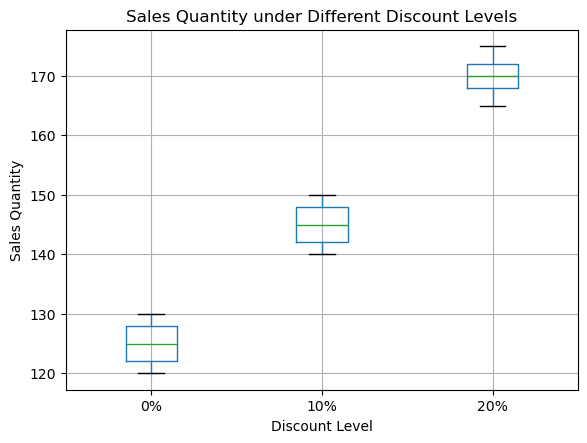

In [151]:
plt.figure()
df.boxplot(column='Sales_Quantity', by='Discount')
plt.title("Sales Quantity under Different Discount Levels")
plt.suptitle("")
plt.xlabel("Discount Level")
plt.ylabel("Sales Quantity")
plt.show()

In [152]:
#q-6 chi-square test
#chi-square goodness-of-fit-test
import pandas as pd
from scipy.stats import chisquare
observed = [190, 185, 90, 35]

# Food categories
categories = ['Vegetarian', 'Non-Vegetarian', 'Low-Calorie', 'Diabetic']

In [153]:
# Total number of passengers
total = 500

# Expected percentages
expected_percentages = [0.35, 0.40, 0.20, 0.05]

# Expected frequencies
expected = [p * total for p in expected_percentages]

expected

[175.0, 200.0, 100.0, 25.0]

In [154]:
df = pd.DataFrame({
    'Food Type': categories,
    'Observed Frequency': observed,
    'Expected Frequency': expected
})

df.head()

,Food Type,Observed Frequency,Expected Frequency
0,Vegetarian,190,175.0
1,Non-Vegetarian,185,200.0
2,Low-Calorie,90,100.0
3,Diabetic,35,25.0


In [155]:
chi_stat, p_value = chisquare(f_obs=observed, f_exp=expected)

print("Chi-Square Statistic:", chi_stat)
print("P-value:", p_value)

Chi-Square Statistic: 7.410714285714286
P-value: 0.05989751420084909


In [156]:
alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis (H0)")
    print("Captain Cook’s belief is NOT true.")
else:
    print("Fail to Reject the Null Hypothesis (H0)")
    print("Captain Cook’s belief is TRUE.")

Fail to Reject the Null Hypothesis (H0)
Captain Cook’s belief is TRUE.


In [ ]:
#ass-9 monte carlo simulation
#normal distribution 
import numpy as np
import matplotlib.pyplot as plt

mu=0
sigma=1
N=1_000_000
samples=np.random.normal(mu,sigma,N)
probability=np.mean(samples<-2)
print("Estimated P(X<-2): ",probability)

plt.hist(samples, bins=200, density=True, alpha=0.6)
plt.axvline(-2, color='red', linestyle='--', label='Threshold = -2')
plt.legend()
plt.title("Normal Distribution Monte Carlo Simulation")
plt.show()

In [ ]:
#uniform distribution
import numpy as np
import matplotlib.pyplot as plt
a,b=0,10
threshold=6
N=500_000
samples=np.random.uniform(a,b,N)
filtered_samples=samples[samples>threshold]
filtered_samples

conditional_mean=np.mean(filtered_samples)
conditional_mean

print("Estimated E[X | X >6]: ",conditional_mean)

plt.hist(samples, bins=100, density=True, alpha=0.5)
plt.axvline(threshold, color='red', linestyle='--', label='Threshold = 6')
plt.legend()
plt.title("Uniform Distribution Monte Carlo Simulation")
plt.show()

In [ ]:
#uniform distribution
import numpy as np
import matplotlib.pyplot as plt

lambda_rate=0.5
N=500_000
time_threshold=5
samples=np.random.exponential(scale=1/lambda_rate,size=N)
samples

survival_prob=np.mean(samples>time_threshold)
survival_prob
print("Estimated P(X>5): " ,survival_prob)

plt.hist(samples, bins=150, density=True, alpha=0.6)
plt.axvline(time_threshold, color='red', linestyle='--', label='Threshold = 5')
plt.legend()
plt.title("Exponential Distribution Monte Carlo Simulation")
plt.show()


In [158]:
#ass-10 factor analyzer bfi data
!pip install factor_analyzer
import pandas as pd
import numpy as np
from factor_analyzer import FactorAnalyzer, calculate_bartlett_sphericity, calculate_kmo
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
print("✅ Libraries imported successfully!")

In [159]:
df = pd.read_csv('bfi.csv')
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (2800, 29)

First 5 rows:


,rownames,A1,A2,A3,A4,A5,C1,C2,C3,C4,...,N4,N5,O1,O2,O3,O4,O5,gender,education,age
0,61617,2.0,4.0,3.0,4.0,4.0,2.0,3.0,3.0,4.0,...,2.0,3.0,3.0,6,3.0,4.0,3.0,1,NaN,16
1,61618,2.0,4.0,5.0,2.0,5.0,5.0,4.0,4.0,3.0,...,5.0,5.0,4.0,2,4.0,3.0,3.0,2,NaN,18
2,61620,5.0,4.0,5.0,4.0,4.0,4.0,5.0,4.0,2.0,...,2.0,3.0,4.0,2,5.0,5.0,2.0,2,NaN,17
3,61621,4.0,4.0,6.0,5.0,5.0,4.0,4.0,3.0,5.0,...,4.0,1.0,3.0,3,4.0,3.0,5.0,2,NaN,17
4,61622,2.0,3.0,3.0,4.0,5.0,4.0,4.0,5.0,3.0,...,4.0,3.0,3.0,3,4.0,3.0,3.0,1,NaN,17


In [160]:
trait_cols = ['A1', 'A2', 'A3', 'A4', 'A5', 'C1', 'C2', 'C3', 'C4', 'C5',
              'E1', 'E2', 'E3', 'E4', 'E5', 'N1', 'N2', 'N3', 'N4', 'N5',
              'O1', 'O2', 'O3', 'O4', 'O5']
print("Selected traits:", trait_cols)
print("\nTrait columns exist in dataset:", all(col in df.columns for col in trait_cols))

Selected traits: ['A1', 'A2', 'A3', 'A4', 'A5', 'C1', 'C2', 'C3', 'C4', 'C5', 'E1', 'E2', 'E3', 'E4', 'E5', 'N1', 'N2', 'N3', 'N4', 'N5', 'O1', 'O2', 'O3', 'O4', 'O5']

Trait columns exist in dataset: True


In [161]:
X = df[trait_cols].apply(pd.to_numeric, errors='coerce').dropna()
X_scaled = StandardScaler().fit_transform(X)
X_scaled

array([[-0.28886722, -0.67600569, -1.21923503, ..., -1.20329269,
        -0.77566784,  0.40128362],
       [-0.28886722, -0.67600569,  0.30621773, ..., -0.37338867,
        -1.61396725,  0.40128362],
       [ 1.84349806, -0.67600569,  0.30621773, ...,  0.45651535,
         0.06263157, -0.35414675],
       ...,
       [-0.28886722, -1.52397164,  0.30621773, ...,  1.28641936,
        -0.77566784,  0.40128362],
       [ 1.84349806, -2.37193759, -1.98196141, ...,  0.45651535,
         0.06263157, -1.10957712],
       [-0.28886722, -1.52397164, -2.74468779, ..., -1.20329269,
         0.06263157, -1.10957712]])

In [ ]:
#step1: Suitability
#test1: bartlett
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
chi_square_value, p_value = calculate_bartlett_sphericity(X_scaled)
p_value# for having correleation it should be less than 5%

#step1: Suitability
#test2: ΚΜΟ
from factor_analyzer.factor_analyzer import calculate_kmo
kmo_all, kmo_model = calculate_kmo(X_scaled)
kmo_model
#it's value should be greater than 0.6

#step2:
#screenplot to know factors with eigenvalue>1
fa = FactorAnalyzer()
fa.fit(X_scaled)
ev, v = fa.get_eigenvalues()
plt.scatter (range (1, X_scaled.shape[1] + 1), ev)
plt.plot(range (1, X_scaled.shape[1] + 1), ev)
plt.title('Scree Plot')
plt.xlabel('Factors')
plt.ylabel('Eigenvalue')
plt.grid()
plt.show()

#Step3
#perform factor loading without using rotation with 5 factors
fa = FactorAnalyzer(n_factors=5, rotation=None)
fa.fit(X_scaled)
loadings = fa.loadings_
loadings

loadings_df = pd.DataFrame (loadings, index=trait_cols, columns=['Factor 1', 'Factor 2', 'Factor 3', 'Factor 4', 'Factor 5'])
loadings_df

#step3 repeat
#perform factor loading with rotation (orthogonal) with 5 factors
fa = FactorAnalyzer(n_factors=5, rotation='varimax')
fa.fit(X_scaled)
loadings = fa. loadings_
loadings

#Create reduced dataset dataframe
reduced_df = pd.DataFrame(fa.transform(X_scaled), index=X.index, columns=['Factor 1', 'Factor 2', 'Factor 3', 'Factor 4', 'Factor 5'])
reduced_df.head()

#now create data file csv with only five factors
reduced_df.to_csv('reduced_data.csv')
reduced_df.head()

In [ ]:
#ass-11 swot analysis
#Qualittaive - strength ,weakness
#quantative- opportunities,threats
#now create data file csv with only five factors
# Weighted SWOT Analysis
strengths = {
"Convenient delivery": (0.4, 5),
"Easy-to-use app": (0.3, 4)
}


weaknesses = {
"High delivery cost": (0.4, 4),
"Low profit margins": (0.3, 3)
}


opportunities = {
"Online grocery demand": (0.4, 5),
"Urban expansion": (0.3, 4)
}


threats = {
"Market competition": (0.4, 4),
"Fuel price rise": (0.3, 3)
}




def calculate_scores(category):
    return {k: w * r for k, (w, r) in category.items()}


print("Strengths:", calculate_scores(strengths))
print("Weaknesses:", calculate_scores(weaknesses))
print("Opportunities:", calculate_scores(opportunities))
print("Threats:", calculate_scores(threats))

# swot to action mapping 
for s in strengths:
    for o in opportunities:
        print(f"Action: Use {s} to capitalize on {o}")

In [ ]:
### Information gathering (Qualitative)
### I.Strength 
#### 1. Convenient doorstep delivery
#### 2. user-friendly mobile application

### II.Weakness
#### 1.High operational and delivery costs
#### 2.Low profit margin

### III.Opportunities (External)
#### 1.Growing demand for online groceries
#### 2.Urban population growth

### IV.Threats (External)
#### 1.Intense competition
#### 2.Rising fuel and logistics costs


#### Highest strength - convenient delivery
#### major weakness- high delivery cost
#### opportunity - growing demand
#### threat- market competition 

In [ ]:
#ass-12 decision analytics operation
# Q-1 Load the diabetes dataset and explore using text and visual analysis to perform 
#identification of attributes.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("diabetes.csv")
df.head(5)
df.isna().sum()
df['Outcome'].value_counts()

sns.countplot(x="Outcome",data=df)
plt.title("Outcome Distribution")
plt.show()

df.hist(figsize=(14,10))
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True)
cmap="coolwarm"
plt.title("Correlation Matrix")
plt.show()

important_features=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin','BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

for i in important_features:
    sns.boxenplot(x="Outcome",y=i,data=df)
    plt.title(f"{i} vs Outcome ")
    plt.show()

df.columns

important_features=['Glucose','BMI','Age','Insulin']

for i in important_features:
    sns.boxenplot(x="Outcome",y=i,data=df)
    plt.title(f"{i} vs Outcome ")
    plt.show()

df.corr()['Outcome'].sort_values(ascending=False)

In [ ]:
#q-2
#Prepare a classification model using different procedures and different sampling techniques
import pandas as pd
import numpy as np

# Visualization 
import matplotlib.pyplot as plt
import seaborn as sns

# Model selection & preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

# Sampling techniques
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

df = pd.read_csv("diabetes.csv")X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5.1 Random (No Resampling)
X_train_random = X_train_scaled
y_train_random = y_train

# 5.2 Oversampling using SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# 5.3 Undersampling
undersample = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = undersample.fit_resample(X_train_scaled, y_train)


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Discriminant Analysis (LDA)": LinearDiscriminantAnalysis(),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(50, 30), max_iter=1000, random_state=42),
    "Support Vector Machine": SVC(kernel="rbf")
}


def train_and_evaluate(model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    cm = confusion_matrix(y_te, y_pred)
    return acc, cm

results = []

for model_name, model in models.items():
    
    # Random Sampling
    acc, cm = train_and_evaluate(
        model,
        X_train_random, y_train_random,
        X_test_scaled, y_test
    )
    results.append([model_name, "Random Sampling", acc, cm])
    
    # SMOTE Oversampling
    acc, cm = train_and_evaluate(
        model,
        X_train_smote, y_train_smote,
        X_test_scaled, y_test
    )
    results.append([model_name, "SMOTE Oversampling", acc, cm])
    
    # Undersampling
    acc, cm = train_and_evaluate(
        model,
        X_train_under, y_train_under,
        X_test_scaled, y_test
    )
    results.append([model_name, "Undersampling", acc, cm])

#display result
results_df = pd.DataFrame(
    results,
    columns=["Model", "Sampling Technique", "Accuracy", "Confusion Matrix"]
)

print("\nModel Performance Summary:")
print(results_df[["Model", "Sampling Technique", "Accuracy"]])

#detailed report
print("\nDetailed Classification Report for Best Model Example:\n")

best_model = LogisticRegression(max_iter=1000)
best_model.fit(X_train_smote, y_train_smote)
y_pred_best = best_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred_best))

In [ ]:
#q-3 Evaluate the performance of the model by preparing a framework and by 
#calculating the Expected Value. During this calculation, assume the cost matrix(in $) as
[99 -1
 #0  45]

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

# Cost Matrix:
# [  99   -0 ]
# [  0    1 ]
#
# Rows    -> Actual Class
# Columns -> Predicted Class
#
# +ve class = Diabetic (1)
# -ve class = Non-Diabetic (0)

C_TP = 99     # True Positive
C_FN = -1    # False Negative
C_FP = 0     # False Positive
C_TN = 1     # True Negative


# (Example values from trained models)

# Example: Model A (e.g., Logistic Regression)
# [[TN, FP],
#  [FN, TP]]
cm_model_A = np.array([[200, 20],
                       [40, 140]])

# Example: Model B (e.g., SVM / Neural Network)
cm_model_B = np.array([[180, 10],
                       [25, 165]])



def expected_value(cm):
    TN, FP = cm[0]
    FN, TP = cm[1]
    EV = (TP * C_TP + FN * C_FN + FP * C_FP + TN * C_TN)
    return EV


EV_model_A = expected_value(cm_model_A)
EV_model_B = expected_value(cm_model_B)


results = pd.DataFrame({
    "Model": ["Model A", "Model B"],
    "Expected Value": [EV_model_A, EV_model_B]
})

print("Expected Value Comparison:\n")
print(results)


if EV_model_A > EV_model_B:
    print("\nDecision: Model A is preferred based on higher expected value.")
else:
    print("\nDecision: Model B is preferred based on higher expected value.")


print("\nInterpretation:")
print("- Expected value incorporates business/medical impact of decisions.")
print("- False negatives are heavily penalized.")
print("- The model with maximum expected value is optimal.")
print("- Accuracy alone is insufficient for decision analytics.")